In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from project.data_manager import DataManager

In [2]:
manager = DataManager()

In [3]:
flights = '../database/flights.csv'
wanted_cols = [
    'MONTH',
    'DAY_OF_WEEK',
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE',
    'DISTANCE',
    'SCHEDULED_ARRIVAL',
    'DELAYED'
]

In [4]:
df = manager.create_flights_dataframe(delay_limit=15, csv_path=flights)

In [5]:
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,DELAYED
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,2359,...,-26.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,2359,...,-16.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,2359,...,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,2359,...,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0


In [52]:
filtered_df = manager.create_df_sample(df=df, percentage=2, wanted_cols=wanted_cols)
#manager.show_stats(filtered_df)

hours_to_transform = [
    'SCHEDULED_DEPARTURE',
    'SCHEDULED_ARRIVAL'
]

# mins_to_transform = [
#     'TAXI_OUT',
#     'DEPARTURE_DELAY',    
# ]

manager.hour_to_sec(df=filtered_df, cols=hours_to_transform)
# manager.min_to_sec(df=filtered_df, cols=mins_to_transform)

filtered_df = manager.create_aux_features(filtered_df=filtered_df)

df_encoded = manager.encode_df(filtered_df)

cols_to_remove = [
                'PERIOD_EVENING', 
                'PERIOD_AFTERNOON', 
                'DAY_OF_WEEK',
                'SCHEDULED_ARRIVAL',
                'DISTANCE',
                'DESTINATION_AIRPORT_COD',
                'ORIGIN_AIRPORT_COD'
                ]

df_encoded = df_encoded.drop(columns=cols_to_remove)

[x_train, x_test, y_train, y_test] = manager.get_test_split(df=df_encoded, target='DELAYED')


In [53]:
#codigo feito por ia tentando debugar
# ratio = total_negativos / total_positivos
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Instanciando o SMOTE
smote = SMOTE(random_state=42)

# 2. Aplicando APENAS nos dados de TREINO 
# (Nunca aplique no teste, senão você avaliará o modelo em dados sintéticos!)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print(f"Antes do SMOTE: {Counter(y_train)}")
print(f"Depois do SMOTE: {Counter(y_train_smote)}")

ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 4. Treinamento do XGBoost
model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=20,
    learning_rate=0.1,
    scale_pos_weight=None,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist' # Acelera o treino em datasets grandes
)

x_train = x_train_smote
y_train = y_train_smote

model_xgb.fit(x_train, y_train)

# 5. Predições e Avaliação
y_pred_xgb = model_xgb.predict(x_test)
y_proba_xgb = model_xgb.predict_proba(x_test)[:, 1]
print('\n\n')
print("--- Relatório de Classificação: XGBoost ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_xgb))
#fazer curva de maneira grafica
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
print('\n\n')
for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    recall_1 = classification_report(y_test, y_pred_t, output_dict=True)['1']['recall']
    precision_1 = classification_report(y_test, y_pred_t, output_dict=True)['1']['precision']
    print(f"Threshold {t:.1f} | Recall: {recall_1:.2f} | Precisão: {precision_1:.2f}")

Antes do SMOTE: Counter({0: 65196, 1: 14800})
Depois do SMOTE: Counter({0: 65196, 1: 65196})



--- Relatório de Classificação: XGBoost ---
              precision    recall  f1-score   support

           0       0.83      0.80      0.82     27941
           1       0.24      0.27      0.26      6343

    accuracy                           0.70     34284
   macro avg       0.53      0.54      0.54     34284
weighted avg       0.72      0.70      0.71     34284

ROC-AUC Score: 0.5777

Matriz de Confusão:
[[22392  5549]
 [ 4604  1739]]



Threshold 0.1 | Recall: 0.78 | Precisão: 0.21
Threshold 0.2 | Recall: 0.60 | Precisão: 0.22
Threshold 0.3 | Recall: 0.47 | Precisão: 0.23
Threshold 0.4 | Recall: 0.36 | Precisão: 0.23
Threshold 0.5 | Recall: 0.27 | Precisão: 0.24


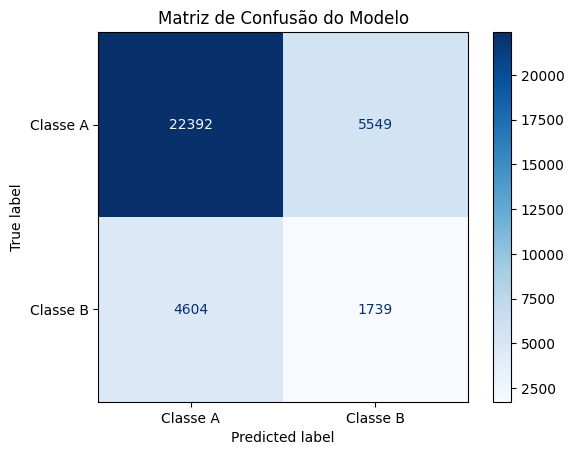

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Supondo que você já tenha:
# y_test: os valores reais
# y_pred: os valores que o seu modelo previu

# 1. Criar a matriz numérica
cm = confusion_matrix(y_test, y_pred_xgb)

# 2. Plotar de forma amigável
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe A', 'Classe B'])
disp.plot(cmap='Blues')

plt.title('Matriz de Confusão do Modelo')
plt.show()

C:\Users\Pedro\AppData\Local\Temp\ipykernel_14816\4062758199.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importancia', y='feature', data=importancias, palette='viridis')


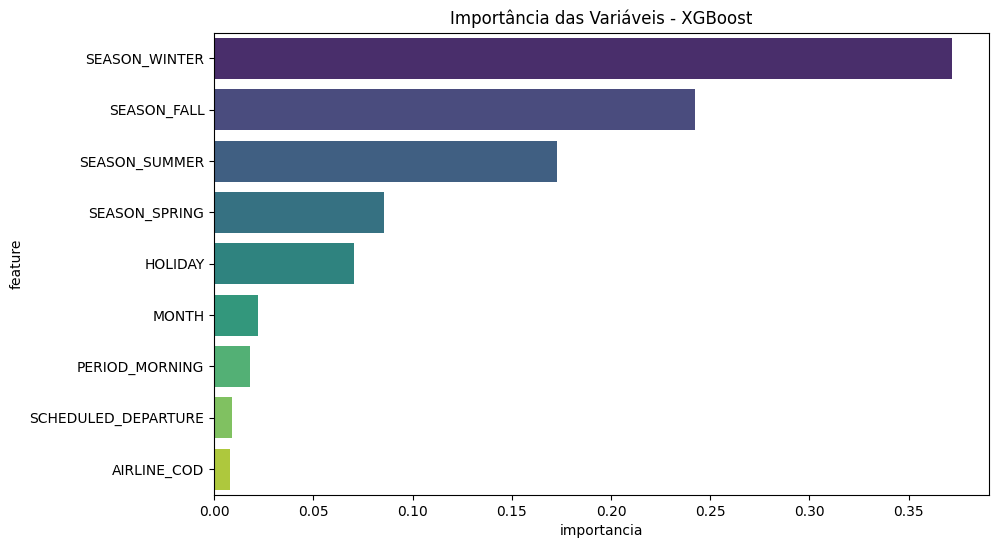

               feature  importancia
6        SEASON_WINTER     0.371982
3          SEASON_FALL     0.242153
5        SEASON_SUMMER     0.172850
4        SEASON_SPRING     0.085554
2              HOLIDAY     0.070311
0                MONTH     0.022254
7       PERIOD_MORNING     0.018068
1  SCHEDULED_DEPARTURE     0.008930
8          AIRLINE_COD     0.007899


In [55]:
# Pegando as importâncias do modelo treinado
importancias = pd.DataFrame({
    'feature': x_train.columns,
    'importancia': model_xgb.feature_importances_
}).sort_values(by='importancia', ascending=False)

# Plotando
plt.figure(figsize=(10, 6))
sns.barplot(x='importancia', y='feature', data=importancias, palette='viridis')
plt.title('Importância das Variáveis - XGBoost')
plt.show()

print(importancias)

In [38]:
# Inicializando o modelo
# n_jobs=-1 usa todos os núcleos do seu i7 para acelerar o treino
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


model_rf = RandomForestClassifier(n_estimators=100, 
                                  max_depth=15, 
                                  random_state=42,
                                  class_weight='balanced', 
                                  n_jobs=-1)

# Treinando
model_rf.fit(x_train, y_train)

# Predições
y_pred = model_rf.predict(x_test)
y_proba = model_rf.predict_proba(x_test)[:, 1]

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Matriz de Confusão para entender Falsos Positivos e Falsos Negativos
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão:")
print(conf_matrix)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.85      0.67      0.75     27941
           1       0.25      0.48      0.33      6343

    accuracy                           0.64     34284
   macro avg       0.55      0.58      0.54     34284
weighted avg       0.74      0.64      0.67     34284

ROC-AUC Score: 0.6014

Matriz de Confusão:
[[18770  9171]
 [ 3292  3051]]


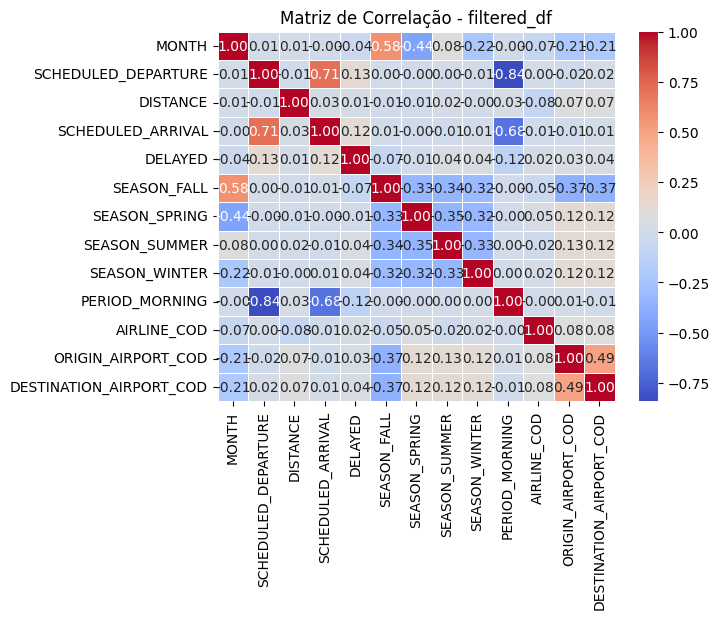

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculando a correlação entre as colunas do filtered_df
# O método .corr() calcula automaticamente a relação entre variáveis numéricas
corr_matrix = df_encoded.corr()

# 2. Criando o Heatmap
# annot=True: exibe os valores numéricos dentro dos quadrados
# cmap='coolwarm': define as cores (azul para negativo, vermelho para positivo)
# fmt=".2f": formata os números para 2 casas decimais
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Ajustes finais de título
plt.title('Matriz de Correlação - filtered_df')

# 4. Salvando o gráfico
plt.savefig('heatmap.png', bbox_inches='tight')